In [ ]:
# Owen Soper
# Machine Learning: Financial Fraud Detection
# 4/19/2026

In [1]:
# imports

# from hw7
import numpy as np
import pandas as pd
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data

from sklearn.pipeline import Pipeline

# hints
from sklearn.metrics import roc_curve, confusion_matrix, RocCurveDisplay
from xgboost import XGBClassifier

# plotting
from xgboost import plot_importance
import matplotlib.pyplot as plt

In [2]:
# initialization

trans = load_data('c://Users//soper//onedrive//Desktop//413projects//finalProject//Fraud_Project_Data')
X = trans.drop('isFraud', axis=1)
y = trans.isFraud
kfold = skm.KFold(random_state=7,
                  shuffle=True)
scaler = StandardScaler(with_mean=True,  with_std=True)
trans.head()

,step,type,amount,nameOrig,nameDest,isFraud
0,259,CASH_OUT,50788.53,C1664090505,C1748285224,0
1,408,CASH_OUT,53965.90,C1166169540,C1826021139,0
2,383,PAYMENT,2277.11,C519273272,M1948478046,0
3,404,CASH_OUT,97034.69,C273857950,C938116643,0
4,690,CASH_IN,123704.39,C1498347648,C1920862069,0


In [ ]:
# problem 1

X1 = X.drop(['nameOrig', 'nameDest'], axis=1)
X1 = pd.get_dummies(X1, drop_first=True, dtype=int)
(X_train, 
X_test, 
y_train, 
y_test) = skm.train_test_split(X1,
                               y,
                               test_size=0.2,
                               stratify=y,
                               random_state=7)
fraud_weight = np.sum(y_train == 0)/np.sum(y_train == 1)


# logistic (ridge) regression

train_model = skl.LogisticRegressionCV(cv=kfold,
                                       class_weight={0:1,1:fraud_weight},
                                       solver='liblinear',
                                       random_state=7)
train_pipe = Pipeline(steps=[('scaler', scaler), ('model', train_model)])
train_pipe.fit(X_train, y_train)
C = train_pipe.named_steps['model'].C_[0]

model = skl.LogisticRegression(C=C, solver='liblinear', random_state=7)
pipe = Pipeline(steps=[('scaler', scaler), ('model', model)])
probs = skm.cross_val_predict(pipe,
                              X_train,
                              y_train,
                              cv=kfold,
                              method='predict_proba')

fpr, tpr, thresholds = roc_curve(y_train, probs[:, 1])
idx = np.argmin(np.abs(tpr - 0.40))
threshold = thresholds[idx]

pipe.fit(X_train, y_train)
predictions = pipe.predict_proba(X_test)
fps = 0
for i in range(len(predictions)):
    if (predictions[i, 1] > threshold) and (y_test.iloc[i] == 0):
        fps += 1
negs = np.sum(y_test == 0)
fprate = fps/negs
print('FPRs')
print(f'Logistic regression (C={C}): {fprate}')


# # XGBoost

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    min_child_weight=5,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=fraud_weight,
    random_state=7,
    n_jobs=2)

xgprobs = skm.cross_val_predict(xgb,
                              X_train,
                              y_train,
                              cv=kfold,
                              method='predict_proba')

fpr, tpr, thresholds = roc_curve(y_train, xgprobs[:, 1])
idx = np.argmin(np.abs(tpr - 0.40))
threshold = thresholds[idx]

xgb.fit(X_train, y_train)
predictions = xgb.predict_proba(X_test)
fps = 0
for i in range(len(predictions)):
    if (predictions[i, 1] > threshold) and (y_test.iloc[i] == 0):
        fps += 1
negs = np.sum(y_test == 0)
fprate = fps/negs
print(f'XGBoost: {fprate}')
print('XGBoost looks the most promising.')

In [ ]:
# problem 2

X2 = pd.DataFrame(X1)
X2['TypeDest'] = X['nameDest'].str[0]
X2 = pd.get_dummies(X2, drop_first=True, dtype=int)
(X2_train, 
X2_test, 
y_train, 
y_test) = skm.train_test_split(X2,
                               y,
                               test_size=0.2,
                               stratify=y,
                               random_state=7)

xgprobs = skm.cross_val_predict(xgb,
                              X2_train,
                              y_train,
                              cv=kfold,
                              method='predict_proba')

fpr, tpr, thresholds = roc_curve(y_train, xgprobs[:, 1])
idx = np.argmin(np.abs(tpr - 0.40))
threshold = thresholds[idx]

xgb.fit(X2_train, y_train)
predictions = xgb.predict_proba(X2_test)
fps = 0
for i in range(len(predictions)):
    if (predictions[i, 1] > threshold) and (y_test.iloc[i] == 0):
        fps += 1
negs = np.sum(y_test == 0)
fprate = fps/negs
print(f'FPR: {fprate}')
print('Slight improvement - keep this feature.')

In [81]:
# problem 3

X3 = pd.DataFrame(X2)
X3['AreaDest'] = X['nameDest'].str[1]
X3 = pd.get_dummies(X3, drop_first=True, dtype=int)
(X3_train, 
X3_test, 
y_train, 
y_test) = skm.train_test_split(X3,
                               y,
                               test_size=0.2,
                               stratify=y,
                               random_state=7)

xgprobs = skm.cross_val_predict(xgb,
                              X3_train,
                              y_train,
                              cv=kfold,
                              method='predict_proba')

fpr, tpr, thresholds = roc_curve(y_train, xgprobs[:, 1])
idx = np.argmin(np.abs(tpr - 0.40))
threshold = thresholds[idx]

xgb.fit(X3_train, y_train)
predictions = xgb.predict_proba(X3_test)
fps = 0
for i in range(len(predictions)):
    if (predictions[i, 1] > threshold) and (y_test.iloc[i] == 0):
        fps += 1
negs = np.sum(y_test == 0)
fprate = fps/negs
print(f'FPR: {fprate}')
print('Worse than baseline - ditch this feature.')

FPR: 0.0030425112258172815
Worse than baseline - ditch this feature.


In [82]:
# problem 4

X4 = pd.DataFrame(X2)
X4['AreaOrig'] = X['nameOrig'].str[1]
X4 = pd.get_dummies(X4, drop_first=True, dtype=int)
(X4_train, 
X4_test, 
y_train, 
y_test) = skm.train_test_split(X4,
                               y,
                               test_size=0.2,
                               stratify=y,
                               random_state=7)

xgprobs = skm.cross_val_predict(xgb,
                              X4_train,
                              y_train,
                              cv=kfold,
                              method='predict_proba')

fpr, tpr, thresholds = roc_curve(y_train, xgprobs[:, 1])
idx = np.argmin(np.abs(tpr - 0.40))
threshold = thresholds[idx]

xgb.fit(X4_train, y_train)
predictions = xgb.predict_proba(X4_test)
fps = 0
for i in range(len(predictions)):
    if (predictions[i, 1] > threshold) and (y_test.iloc[i] == 0):
        fps += 1
negs = np.sum(y_test == 0)
fprate = fps/negs
print(f'FPR: {fprate}')
print('Worse than baseline - ditch this feature.')

FPR: 0.003113328297452684
Worse than baseline - ditch this feature.


In [ ]:
# problem 5

X5 = pd.DataFrame(X2)
HourOfDay = (X5.step - 1)%24 + 1
bins = [0, 6, 12, 18, 24]
labels = ['night', 'morning', 'afternoon', 'evening']
X5['PartOfDay'] = pd.cut(
    HourOfDay,
    bins=bins,
    labels=labels,
)
X5 = pd.get_dummies(X5, drop_first=True, dtype=int)
(X5_train, 
X5_test, 
y_train, 
y_test) = skm.train_test_split(X5,
                               y,
                               test_size=0.2,
                               stratify=y,
                               random_state=7)

xgprobs = skm.cross_val_predict(xgb,
                              X5_train,
                              y_train,
                              cv=kfold,
                              method='predict_proba')

fpr, tpr, thresholds = roc_curve(y_train, xgprobs[:, 1])
idx = np.argmin(np.abs(tpr - 0.40))
threshold = thresholds[idx]

xgb.fit(X5_train, y_train)
predictions = xgb.predict_proba(X5_test)
fps = 0
for i in range(len(predictions)):
    if (predictions[i, 1] > threshold) and (y_test.iloc[i] == 0):
        fps += 1
negs = np.sum(y_test == 0)
fprate = fps/negs
print(f'FPR: {fprate}')
print('Good improvement - keep this feature.')

In [7]:
#problem 6

X6 = pd.DataFrame(X5)
X6['DayOfWeek'] = ((X6.step - 1)//24)%7 + 1
X6 = pd.get_dummies(X6, columns=['DayOfWeek'], drop_first=True, dtype=int)
(X6_train, 
X6_test, 
y_train, 
y_test) = skm.train_test_split(X6,
                               y,
                               test_size=0.2,
                               stratify=y,
                               random_state=7)

xgprobs = skm.cross_val_predict(xgb,
                              X6_train,
                              y_train,
                              cv=kfold,
                              method='predict_proba')

fpr, tpr, thresholds = roc_curve(y_train, xgprobs[:, 1])
idx = np.argmin(np.abs(tpr - 0.40))
threshold = thresholds[idx]

xgb.fit(X6_train, y_train)
predictions = xgb.predict_proba(X6_test)
fps = 0
for i in range(len(predictions)):
    if (predictions[i, 1] > threshold) and (y_test.iloc[i] == 0):
        fps += 1
negs = np.sum(y_test == 0)
fprate = fps/negs
print(f'FPR: {fprate}')
print('Good improvement - keep this feature.')

FPR: 0.0008576734231398715
Good improvement - keep this feature.


In [8]:
# problem 8

def net_benefit(y_true ,prob ,thr):
    pred = (prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true ,pred).ravel()
    return 1000*tp - 10*fp

thresholds = np.linspace(0 , 1 , 400)
best_thr = None
best_val = -1e9
for t in thresholds:
    val = net_benefit(y_train, xgprobs[:, 1], t)
    if val > best_val:
        best_val = val
        best_thr = t

print('Threshold:', best_thr)

fps = ((predictions[:, 1] > best_thr) & (y_test == 0)).sum()
tps = ((predictions[:, 1] > best_thr) & (y_test == 1)).sum()
cost = fps*10
benefit = tps*1000
print(f'Test profit: ${benefit - cost}')

Threshold: 0.7142857142857142
Test profit: $1153720


Final feature set:


,step,amount,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,TypeDest_M,PartOfDay_morning,PartOfDay_afternoon,PartOfDay_evening,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,DayOfWeek_6,DayOfWeek_7
0,259,50788.53,1,0,0,0,0,0,0,1,0,0,1,0,0,0


c:\Users\soper\OneDrive\Desktop\413projects\islp\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\soper\OneDrive\Desktop\413projects\islp\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Logistic feature importance:


,feature,coefficient,abs_coeff
2,type_CASH_OUT,4.455497,4.455497
5,type_TRANSFER,2.924859,2.924859
8,PartOfDay_afternoon,-2.380772,2.380772
9,PartOfDay_evening,-1.961140,1.961140
7,PartOfDay_morning,-1.829466,1.829466
0,step,0.704026,0.704026
13,DayOfWeek_5,0.237167,0.237167
4,type_PAYMENT,-0.203303,0.203303
6,TypeDest_M,-0.203303,0.203303
3,type_DEBIT,-0.156555,0.156555


<Figure size 1000x600 with 0 Axes>

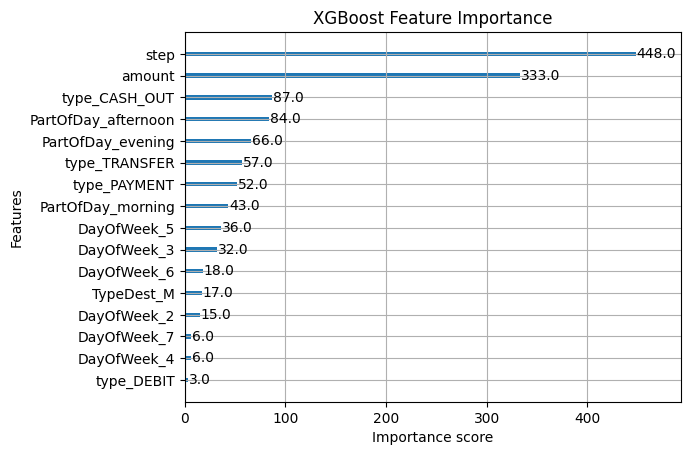

In [9]:
# feature summary

print('Final feature set:')
display(X6.head(1))



# logistic feature importance

train_model = skl.LogisticRegressionCV(cv=kfold,
                                       class_weight={0:1,1:fraud_weight},
                                       solver='liblinear',
                                       random_state=7)
train_pipe = Pipeline(steps=[('scaler', scaler), ('model', train_model)])
train_pipe.fit(X6_train, y_train)
C = train_pipe.named_steps['model'].C_[0]

model = skl.LogisticRegression(C=C, solver='liblinear', random_state=7)
pipe = Pipeline(steps=[('scaler', scaler), ('model', model)])
pipe.fit(X6_train, y_train)

print("Logistic feature importance:")
coef = pipe.named_steps['model'].coef_[0]
features = X6.columns
importance = pd.DataFrame({
    'feature': features,
    'coefficient': coef,
    'abs_coeff': np.abs(coef)
}).sort_values('abs_coeff', ascending=False)
display(importance)


# XGBoost feature importance

plt.figure(figsize=(10, 6))
plot_importance(xgb, max_num_features=20)
plt.title("XGBoost Feature Importance")
plt.show()

Logistic - calibrated test profit: $877640
XGBoost - calibrated test profit: $1153720

Best model: XGBoost


c:\Users\soper\OneDrive\Desktop\413projects\islp\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\soper\OneDrive\Desktop\413projects\islp\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


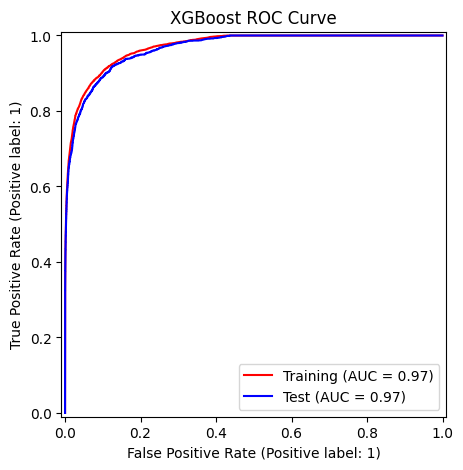

In [11]:
# Best model analysis


# logistic (ridge) regression (found above)

probs = skm.cross_val_predict(pipe,
                              X_train,
                              y_train,
                              cv=kfold,
                              method='predict_proba')
thresholds = np.linspace(0 , 1 , 400)
best_thr = None
best_val = -1e9
for t in thresholds:
    val = net_benefit(y_train, probs[:, 1], t)
    if val > best_val:
        best_val = val
        best_thr = t


predictions = pipe.predict_proba(X6_test)
fps = ((predictions[:, 1] > best_thr) & (y_test == 0)).sum()
tps = ((predictions[:, 1] > best_thr) & (y_test == 1)).sum()
costLog = fps*10
benefitLog = tps*1000
print(f'Logistic - calibrated test profit: ${benefitLog - costLog}')


# XGBoost (model found in problem 5)

print(f'XGBoost - calibrated test profit: ${benefit - cost}')
print()
print('Best model: XGBoost')

roc_curve = RocCurveDisplay.from_estimator
fig, ax = plt.subplots(figsize=(12,5))

for (x_val, y_val, c, name) in zip(
    (X6_train, X6_test),
    (y_train, y_test),
    ('r', 'b'),
    ('Training',
     'Test')):
    roc_curve(xgb,
              x_val,
              y_val,
              name=name,
              ax=ax,
              color=c)
ax.set_title("XGBoost ROC Curve");